# 03 — Clustering (K-Means) — M1 Product Purchase Data

**Input:** `data/processed/processed_m1_data.csv`  
**Output:** `data/processed/clustered_m1_data.csv`, `models/kmeans_m1_model.pkl`

In [1]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from pathlib import Path
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pickle
import warnings
warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/cluster')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = pd.read_csv('../data/processed/processed_m1_data.csv')
print("Processed M1 data shape:", df.shape)

# Drop target (m1_purchase) for clustering — clustering is unsupervised
if 'm1_purchase' in df.columns:
    df_features = df.drop(columns=['m1_purchase'])
    target = df['m1_purchase']
    print(f'✓ Dropped m1_purchase for clustering | Features shape: {df_features.shape}')
else:
    df_features = df.copy()
    target = None

# KMeans/PCA require finite values — drop columns that are entirely NaN (e.g. mis-encoded categoricals)
_all_nan_cols = df_features.columns[df_features.isna().all()].tolist()
if _all_nan_cols:
    df_features = df_features.drop(columns=_all_nan_cols)
    print(f'✓ Dropped all-NaN feature columns (no usable signal): {_all_nan_cols}')

if df_features.isna().any().any():
    nan_cols = df_features.columns[df_features.isna().any()].tolist()
    raise ValueError(
        f'Features still contain NaN after cleanup. Columns with NaN: {nan_cols}. '
        'Re-run 02_preprocessing.ipynb (check user_pcmac / categorical encoding).'
    )


Processed M1 data shape: (133, 22)
✓ Dropped m1_purchase for clustering | Features shape: (133, 21)


# Elbow Method

In [3]:
inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_features)  # Use features only, not target
    inertias.append(km.inertia_)

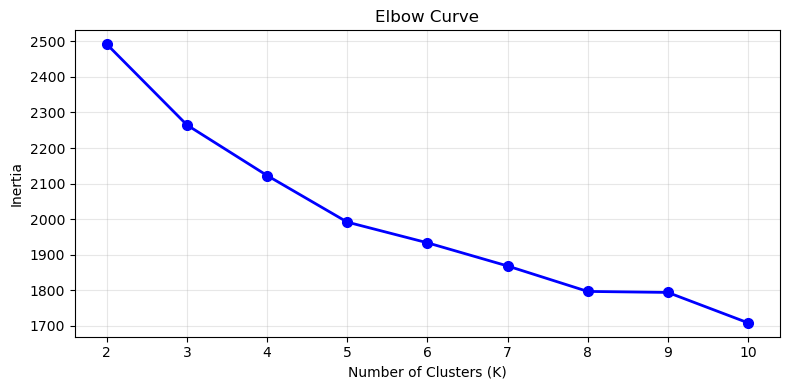

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'elbow_curve.png', dpi=150)
plt.show()

In [5]:
# From the elbow curve, we can see that the optimal number of clusters is around 4 or 5. Let's choose K=5 for our final model.
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_features)  # Fit on features only

print('Cluster distribution:')
print(pd.Series(clusters).value_counts().sort_index())

Cluster distribution:
0    29
1    33
2    24
3    30
4    17
Name: count, dtype: int64


# PCA visualization

In [6]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(df_features)  # Use features only
pca_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

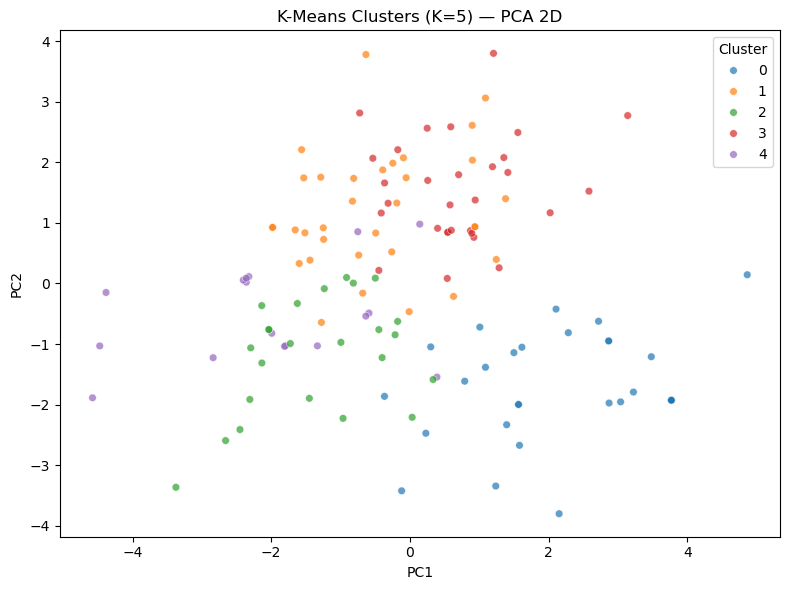

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7, s=30)
plt.title(f'K-Means Clusters (K={k_optimal}) — PCA 2D')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cluster_scatter.png', dpi=150)
plt.show()

# save clustered data and model

In [8]:
raw = pd.read_csv('../data/raw/M1_data.csv')
# Add cluster assignments - align with the indices of df_features (which may have had NaNs removed)
raw_aligned = raw.iloc[df_features.index].reset_index(drop=True)
raw_aligned['Cluster'] = clusters
raw_aligned.to_csv('../data/processed/clustered_m1_data.csv', index=False)
print(f'Saved clustered_m1_data.csv — shape: {raw_aligned.shape}')

Saved clustered_m1_data.csv — shape: (133, 23)


In [9]:
with open('../models/kmeans_m1_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print('Saved kmeans_m1_model.pkl')

Saved kmeans_m1_model.pkl


In [10]:
# Cluster profiles — select first 3 numeric features for profiling
numeric_features = raw_aligned.select_dtypes(include='number').drop(columns=['Cluster'], errors='ignore').columns.tolist()
profile_features = numeric_features[:3] if len(numeric_features) >= 3 else numeric_features

print('\nCluster Profiles (Mean values of key features):')
if profile_features:
    print(raw_aligned.groupby('Cluster')[profile_features].mean().round(2))
else:
    print("No numeric features available for profiling")


Cluster Profiles (Mean values of key features):
         interest_computers  age_computer  appleproducts_count
Cluster                                                       
0                      3.76          3.62                 3.83
1                      3.52          2.33                 2.48
2                      3.38          4.38                 2.71
3                      4.87          1.47                 3.80
4                      4.06          4.29                 0.71


In [11]:
# Calculate cluster quality metrics
silhouette = silhouette_score(df_features, clusters)  # Use features only
davies_bouldin = davies_bouldin_score(df_features, clusters)
calinski_harabasz = calinski_harabasz_score(df_features, clusters)

print('=== Cluster Quality Metrics ===')
print(f'Silhouette Score: {silhouette:.4f}')
print(f'  → Range [-1, 1]: >0.5 = good, >0.7 = excellent')
print(f'\nDavies-Bouldin Index: {davies_bouldin:.4f}')
print(f'  → Range [0, ∞]: Lower is better, <1 = excellent')
print(f'\nCalinski-Harabasz Index: {calinski_harabasz:.4f}')
print(f'  → Range [0, ∞]: Higher is better, >30 = good')
print('\n✓ Clustering quality validated!' if silhouette > 0.5 else '\n⚠ Consider different K value')

=== Cluster Quality Metrics ===
Silhouette Score: 0.1053
  → Range [-1, 1]: >0.5 = good, >0.7 = excellent

Davies-Bouldin Index: 2.2495
  → Range [0, ∞]: Lower is better, <1 = excellent

Calinski-Harabasz Index: 12.8793
  → Range [0, ∞]: Higher is better, >30 = good

⚠ Consider different K value
